# Publication-quality MSA of 10 K-RAS homologs

This notebook builds a reference-guided multiple sequence alignment for ten homologous K-RAS proteins and renders a publication-quality figure with residue-class coloring, column conservation, consensus sequence, and annotated functional regions.

The input FASTA is [kras_homologs_10.fasta](./kras_homologs_10.fasta), which contains ten UniProt-derived K-RAS homologs from vertebrates and mammals.

## Requirements

This notebook uses **Python**, **Biopython**, **NumPy**, and **Matplotlib**. If Biopython is missing in your Jupyter kernel, install it first with:

```python
%pip install biopython
```

The workflow does not depend on `clustalo` or `muscle`: the alignment is constructed in pure Python using `Bio.Align.PairwiseAligner` and a reference-guided merge strategy.

## Method

Let the human K-RAS sequence be the reference $R$ of length $L$, and let $X_1,\dots,X_n$ be the homologous sequences. For each query sequence $X_i$, the notebook computes a global alignment against $R$ with **BLOSUM62** and affine gap penalties. This produces, for each reference position, either a matched residue, a deletion, or a short insertion between two consecutive reference residues.

The multiple alignment is then assembled by taking, at each insertion boundary $j \in \{0,\dots,L\}$, the maximum insertion length across all pairwise alignments and padding the shorter insertions with gaps. This yields a common aligned coordinate system without relying on an external MSA binary.

For each alignment column $k$, the notebook also computes:

- the **consensus residue** as the most frequent non-gap symbol,
- the **conservation score**
  $$c_k = 
rac{\max_a n_k(a)}{\sum_a n_k(a)},$$
  where $n_k(a)$ is the count of residue $a$ among non-gap symbols in column $k$.

These quantities are displayed together with K-RAS functional regions such as the P-loop, Switch I, Switch II, and the hypervariable tail.

In [2]:
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from Bio import AlignIO, SeqIO
from Bio.Align import PairwiseAligner, MultipleSeqAlignment, substitution_matrices
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

INPUT_FASTA = Path('kras_homologs_10.fasta')
ALIGNED_FASTA = Path('kras_homologs_10_aligned.fasta')
FIGURES_DIR = Path('../figures')
OUTPUT_PNG = FIGURES_DIR / 'sequenceTols_kras_msa.png'
OUTPUT_PDF = FIGURES_DIR / 'sequenceTols_kras_msa.pdf'
CHUNK_SIZE = 60

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
})


In [3]:
REGIONS = [
    ('P-loop', 10, 17, '#d7ecff'),
    ('Switch I', 30, 38, '#dff5df'),
    ('Switch II', 59, 67, '#fde2d7'),
    ('Hypervariable', 167, 189, '#efe3fb'),
]

RESIDUE_COLORS = {
    'A': '#f0e0b6', 'V': '#f0e0b6', 'L': '#f0e0b6', 'I': '#f0e0b6', 'M': '#f0e0b6',
    'F': '#d8c4f2', 'Y': '#d8c4f2', 'W': '#d8c4f2',
    'S': '#cfeec8', 'T': '#cfeec8', 'N': '#cfeec8', 'Q': '#cfeec8',
    'K': '#c8dcff', 'R': '#c8dcff', 'H': '#c8dcff',
    'D': '#f7c6c6', 'E': '#f7c6c6',
    'G': '#ffd59e', 'P': '#fff1a8', 'C': '#f6d1f0',
    '-': '#f2f2f2', 'X': '#e5e5e5',
}

SHORT_NAMES = {
    'KRAS_HUMAN_P01116': 'Human',
    'KRAS_MOUSE_P32883': 'Mouse',
    'KRAS_RAT_P08644': 'Rat',
    'KRAS_OPOSSUM_Q07983': 'Opossum',
    'KRAS_TURKEY_P79800': 'Turkey',
    'KRAS_XENOPUS_Q05147': 'Xenopus',
    'KRAS_CARP_Q9YH38': 'Carp',
    'KRAS_KILLIFISH_Q5EFX7': 'Killifish',
    'KRAS_MOLERAT_G5BQA1': 'Mole-rat',
    'KRAS_ZEBRAFISH_A0A2R8Q8S1': 'Zebrafish',
}

def residue_color(residue: str) -> str:
    return RESIDUE_COLORS.get(residue, '#e5e5e5')

def short_name(record_id: str) -> str:
    return SHORT_NAMES.get(record_id, record_id)


In [4]:
def pairwise_alignment_strings(reference: str, query: str, aligner: PairwiseAligner):
    alignment = aligner.align(reference, query)[0]
    coordinates = alignment.coordinates
    ref_chunks = []
    query_chunks = []
    for step in range(coordinates.shape[1] - 1):
        ref_start, ref_end = coordinates[0, step], coordinates[0, step + 1]
        query_start, query_end = coordinates[1, step], coordinates[1, step + 1]
        ref_span = ref_end - ref_start
        query_span = query_end - query_start
        if ref_span > 0 and query_span > 0:
            ref_chunks.append(reference[ref_start:ref_end])
            query_chunks.append(query[query_start:query_end])
        elif ref_span > 0:
            ref_chunks.append(reference[ref_start:ref_end])
            query_chunks.append('-' * ref_span)
        elif query_span > 0:
            ref_chunks.append('-' * query_span)
            query_chunks.append(query[query_start:query_end])
    return ''.join(ref_chunks), ''.join(query_chunks)

def reference_guided_msa(records):
    records = list(records)
    reference_record = records[0]
    reference = str(reference_record.seq)
    aligner = PairwiseAligner(mode='global')
    aligner.substitution_matrix = substitution_matrices.load('BLOSUM62')
    aligner.open_gap_score = -10
    aligner.extend_gap_score = -0.5

    insertion_maxima = [0] * (len(reference) + 1)
    parsed = []
    for record in records:
        aligned_reference, aligned_query = pairwise_alignment_strings(reference, str(record.seq), aligner)
        insertions = [''] * (len(reference) + 1)
        aligned_positions = ['-'] * len(reference)
        ref_index = 0
        for ref_char, query_char in zip(aligned_reference, aligned_query):
            if ref_char == '-':
                if query_char != '-':
                    insertions[ref_index] += query_char
            else:
                aligned_positions[ref_index] = query_char if query_char != '-' else '-'
                ref_index += 1
        for idx, insertion in enumerate(insertions):
            insertion_maxima[idx] = max(insertion_maxima[idx], len(insertion))
        parsed.append((record, insertions, aligned_positions))

    aligned_records = []
    for record, insertions, aligned_positions in parsed:
        parts = []
        for idx, residue in enumerate(reference):
            insertion = insertions[idx]
            parts.append(insertion + '-' * (insertion_maxima[idx] - len(insertion)))
            parts.append(aligned_positions[idx])
        tail = insertions[len(reference)]
        parts.append(tail + '-' * (insertion_maxima[len(reference)] - len(tail)))
        aligned_sequence = ''.join(parts)
        aligned_records.append(SeqRecord(Seq(aligned_sequence), id=record.id, description=record.description))

    return MultipleSeqAlignment(aligned_records), reference_record.id

def reference_position_map(reference_aligned: str):
    mapping = []
    residue_index = 0
    for char in reference_aligned:
        if char == '-':
            mapping.append(None)
        else:
            residue_index += 1
            mapping.append(residue_index)
    return mapping

def consensus_and_conservation(msa):
    matrix = np.array([list(str(record.seq)) for record in msa], dtype='U1')
    consensus = []
    conservation = []
    for column in matrix.T:
        nongap = [residue for residue in column if residue != '-']
        if not nongap:
            consensus.append('-')
            conservation.append(0.0)
            continue
        residue, count = Counter(nongap).most_common(1)[0]
        consensus.append(residue)
        conservation.append(count / len(nongap))
    return ''.join(consensus), np.asarray(conservation, dtype=float), matrix


In [5]:
records = list(SeqIO.parse(INPUT_FASTA, 'fasta'))
if len(records) != 10:
    raise ValueError(f'Expected 10 K-RAS homologs, found {len(records)}.')

msa, reference_id = reference_guided_msa(records)
AlignIO.write(msa, ALIGNED_FASTA, 'fasta')

consensus, conservation, matrix = consensus_and_conservation(msa)
reference_aligned = str(msa[0].seq)
reference_positions = reference_position_map(reference_aligned)

print(f'Aligned {len(msa)} sequences with length {msa.get_alignment_length()} columns.')
print(f'Reference: {reference_id}')
print(f'Wrote aligned FASTA: {ALIGNED_FASTA}')
print(f'Mean column conservation: {conservation.mean():.3f}')


Aligned 10 sequences with length 189 columns.
Reference: KRAS_HUMAN_P01116
Wrote aligned FASTA: kras_homologs_10_aligned.fasta
Mean column conservation: 0.944


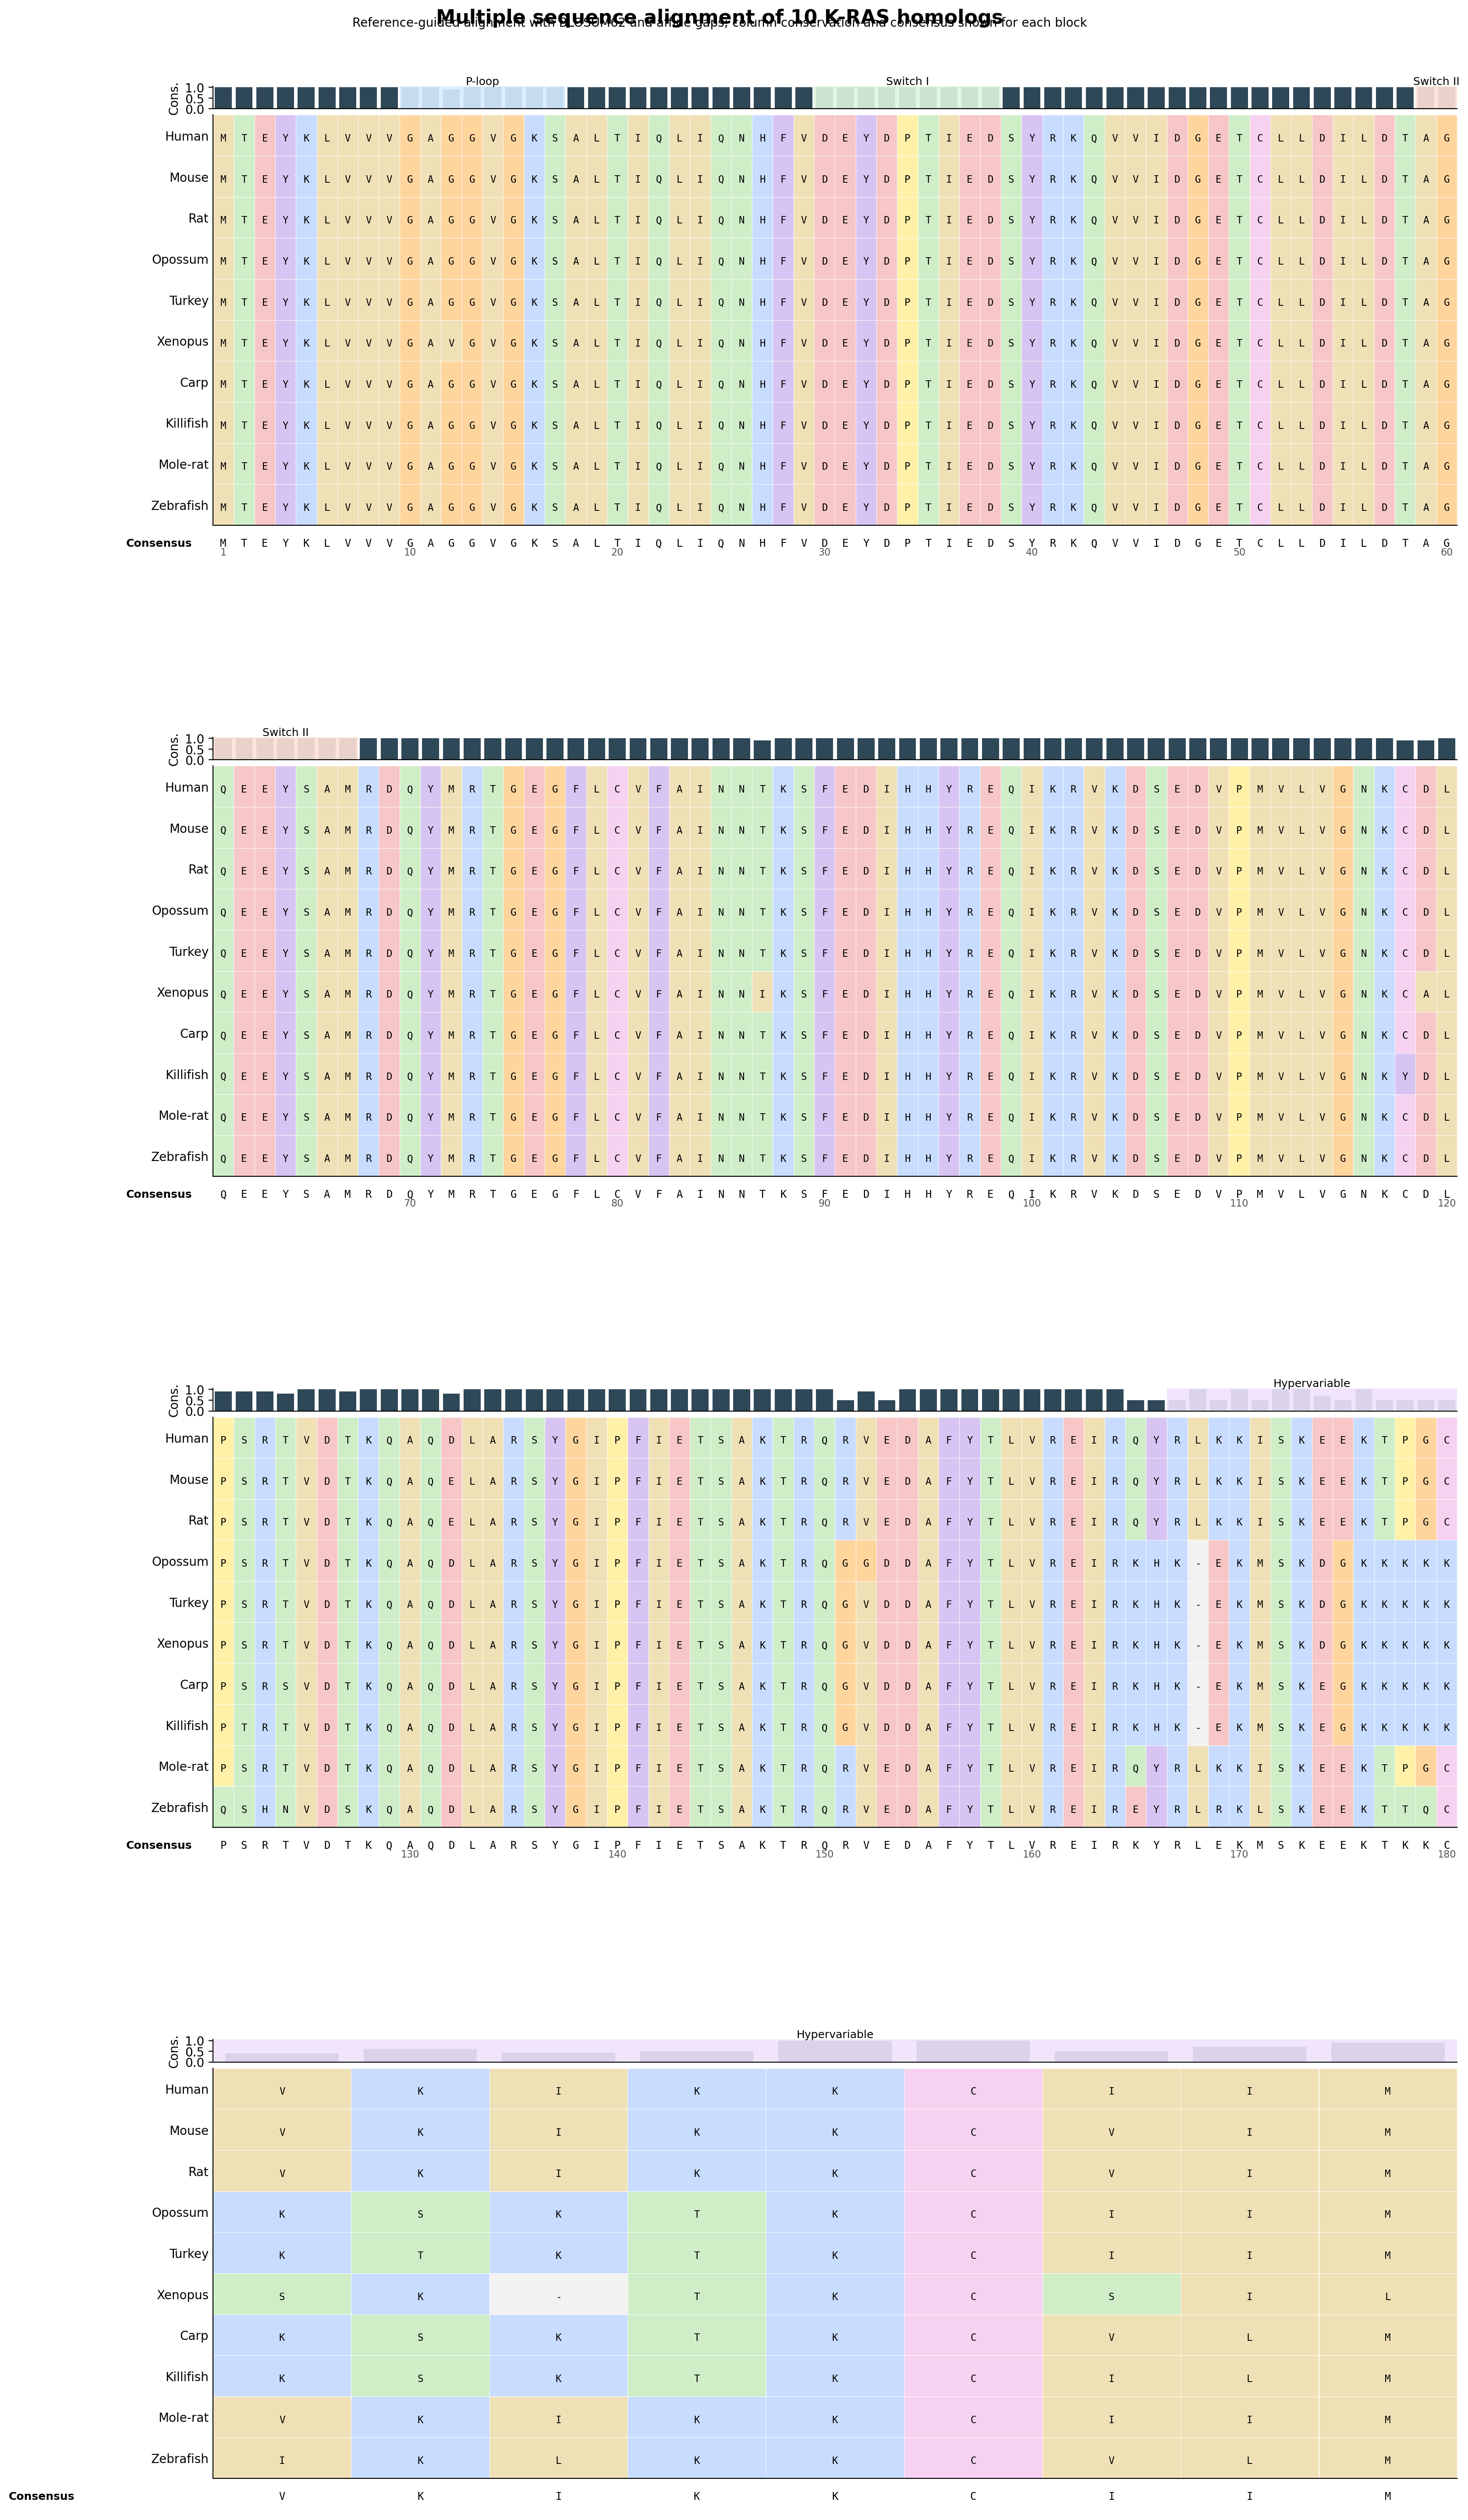

Saved figure: ../figures/sequenceTols_kras_msa.png
Saved figure: ../figures/sequenceTols_kras_msa.pdf


In [6]:
def plot_msa(msa, consensus, conservation, reference_positions, output_png, output_pdf, chunk_size=60):
    labels = [short_name(record.id) for record in msa]
    sequences = [str(record.seq) for record in msa]
    n_sequences = len(sequences)
    alignment_length = len(sequences[0])
    n_chunks = int(np.ceil(alignment_length / chunk_size))

    fig_height = n_chunks * (0.55 * n_sequences + 1.9)
    fig = plt.figure(figsize=(17, fig_height), dpi=200)
    outer = fig.add_gridspec(n_chunks, 1, hspace=0.38)

    for chunk_index in range(n_chunks):
        start = chunk_index * chunk_size
        end = min((chunk_index + 1) * chunk_size, alignment_length)
        inner = outer[chunk_index].subgridspec(3, 1, height_ratios=[0.55, n_sequences, 0.65], hspace=0.04)
        ax_top = fig.add_subplot(inner[0])
        ax_main = fig.add_subplot(inner[1])
        ax_bottom = fig.add_subplot(inner[2])

        x_positions = np.arange(start, end)
        conservation_slice = conservation[start:end]
        ax_top.bar(x_positions + 0.5, conservation_slice, width=0.82, color='#2f4858')
        ax_top.set_xlim(start, end)
        ax_top.set_ylim(0, 1.05)
        ax_top.set_ylabel('Cons.')
        ax_top.set_yticks([0, 0.5, 1.0])
        ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        for region_name, region_start, region_end, color in REGIONS:
            region_columns = [idx for idx in range(start, end) if reference_positions[idx] is not None and region_start <= reference_positions[idx] <= region_end]
            if region_columns:
                left = min(region_columns)
                right = max(region_columns) + 1
                ax_top.axvspan(left, right, color=color, alpha=0.9, lw=0)
                ax_top.text((left + right) / 2, 1.02, region_name, ha='center', va='bottom', fontsize=9)

        ax_main.set_xlim(start, end)
        ax_main.set_ylim(n_sequences, 0)
        ax_main.set_yticks(np.arange(n_sequences) + 0.5)
        ax_main.set_yticklabels(labels)
        ax_main.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        ax_main.tick_params(axis='y', length=0)
        for y_index, sequence in enumerate(sequences):
            for x_index in range(start, end):
                residue = sequence[x_index]
                ax_main.add_patch(Rectangle((x_index, y_index), 1, 1, facecolor=residue_color(residue), edgecolor='white', linewidth=0.35))
                ax_main.text(x_index + 0.5, y_index + 0.57, residue, ha='center', va='center', fontsize=8.1, family='DejaVu Sans Mono')
        for x_index in range(start, end + 1):
            ax_main.axvline(x_index, color='white', linewidth=0.35, zorder=0)
        for y_index in range(n_sequences + 1):
            ax_main.axhline(y_index, color='white', linewidth=0.35, zorder=0)

        consensus_slice = consensus[start:end]
        ax_bottom.set_xlim(start, end)
        ax_bottom.set_ylim(0, 1)
        ax_bottom.axis('off')
        ax_bottom.text(start - 1.0, 0.55, 'Consensus', ha='right', va='center', fontsize=9, fontweight='bold')
        for x_index, residue in zip(range(start, end), consensus_slice):
            ax_bottom.text(x_index + 0.5, 0.55, residue, ha='center', va='center', fontsize=8.6, family='DejaVu Sans Mono')
        tick_positions = []
        tick_labels = []
        for x_index in range(start, end):
            ref_pos = reference_positions[x_index]
            if ref_pos is not None and (ref_pos == 1 or ref_pos % 10 == 0):
                tick_positions.append(x_index + 0.5)
                tick_labels.append(str(ref_pos))
        for x_tick, tick_label in zip(tick_positions, tick_labels):
            ax_bottom.text(x_tick, 0.02, tick_label, ha='center', va='bottom', fontsize=8, color='#555555')

    fig.suptitle('Multiple sequence alignment of 10 K-RAS homologs', fontsize=16, fontweight='bold', y=0.995)
    fig.text(0.5, 0.988, 'Reference-guided alignment with BLOSUM62 and affine gaps; column conservation and consensus shown for each block', ha='center', fontsize=10)
    fig.subplots_adjust(left=0.16, right=0.995, top=0.965, bottom=0.03)
    fig.savefig(output_png, dpi=300, bbox_inches='tight')
    fig.savefig(output_pdf, bbox_inches='tight')
    return fig

fig = plot_msa(msa, consensus, conservation, reference_positions, OUTPUT_PNG, OUTPUT_PDF, chunk_size=CHUNK_SIZE)
plt.show()
print(f'Saved figure: {OUTPUT_PNG}')
print(f'Saved figure: {OUTPUT_PDF}')


## Interpretation

This figure is designed for direct inspection of conservation and local divergence in a small homologous protein family. For K-RAS, the GTPase core remains highly conserved, whereas the C-terminal hypervariable region shows stronger species-specific variation.

Because the alignment is reference-guided, the column numbering follows the human K-RAS sequence. For larger and more diverse families, an external MSA engine such as Clustal Omega or MAFFT may be preferable, but for this compact homologous set the Biopython-based workflow remains fully reproducible inside the notebook.